In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from datasets import load_dataset

dataset = load_dataset("AI-Lab-Makerere/beans")

README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

In [3]:
#dataset

In [4]:
#dataset["train"]

In [5]:
#dataset["train"].features

# EDA

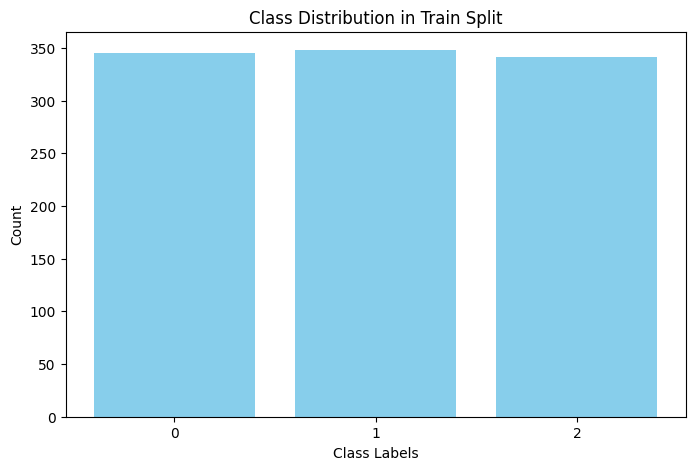

In [6]:
#View the distribution of classes in the train split
import matplotlib.pyplot as plt
from collections import Counter


# Get labels from the train split
labels = [example['labels'] for example in dataset['train']]

# Count occurrences of each label
label_counts = Counter(labels)

# Plot distribution
plt.figure(figsize=(8, 5))
plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
plt.xlabel('Class Labels')
plt.ylabel('Count')
plt.title('Class Distribution in Train Split')
plt.xticks(ticks=list(label_counts.keys()), labels=[str(k) for k in label_counts.keys()])
plt.show()


In [7]:
#Map Class Names and indexes
#print(label_counts)
#print(f"angular_leaf_spot: {label_counts[0]}, bean_rust: {label_counts[1]}, healthy: {label_counts[2]}")

# Data Augmentation

In [8]:
pip install albumentations opencv-python

Note: you may need to restart the kernel to use updated packages.


In [9]:
# Augment the dataset with Albumentation
import os
import cv2
import numpy as np
#from datasets import load_dataset
import albumentations as A
from PIL import Image

# Load dataset
#dataset = load_dataset("AI-Lab-Makerere/beans")

# Define Albumentations transformations
transform = A.Compose([
    A.RandomRotate90(),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.GaussianBlur(p=0.2),
])


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [10]:
label_names = ('angular_leaf_spot', 'bean_rust', 'healthy')

In [11]:
# Function to augment and save images in class-specific folders
def augment_and_save(split_name, factor=10):
    split = dataset[split_name]
    
    for idx, example in enumerate(split):
        img = np.array(example["image"])  # Convert PIL Image to NumPy array
        label = example["labels"]
        class_name = label_names[label]  # Convert label index to class name
        
        # Create class-specific directory
        class_dir = os.path.join(output_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        # Save original image
        original_path = os.path.join(class_dir, f"{split_name}_{idx}_original.jpg")
        Image.fromarray(img).save(original_path)

        # Generate augmented images
        for i in range(factor - 1):  # Already have 1 original, so (factor - 1) more
            augmented = transform(image=img)['image']  # Apply augmentation
            aug_path = os.path.join(class_dir, f"{split_name}_{idx}_aug_{i}.jpg")
            Image.fromarray(augmented).save(aug_path)

In [12]:
# Augment the train split
# Directory to save augmented images
output_dir = "augmented_train"
os.makedirs(output_dir, exist_ok=True)

augment_and_save("train", factor=40)

print(f"Augmented images saved in '{output_dir}'")

Augmented images saved in 'augmented_train'


In [13]:
# Augment the validation split
# Directory to save augmented images
output_dir = "augmented_validation"
os.makedirs(output_dir, exist_ok=True)

augment_and_save("validation", factor=40)

print(f"Augmented images saved in '{output_dir}'")

Augmented images saved in 'augmented_validation'


In [14]:
# Investigate output augmented data directory

#os.listdir("/kaggle/working/")

In [15]:
#len(os.listdir("/kaggle/working/augmented_validation/healthy"))